In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
train = pd.read_csv('../data/raw/UNSW_NB15_training-set.csv')
test = pd.read_csv('../data/raw/UNSW_NB15_testing-set.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

/var/folders/s9/5g6t7vwn40ngmg0cqw8zz1nh0000gn/T/ipykernel_17684/1149408415.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Train shape: (82332, 45)
Test shape: (175341, 45)


In [2]:
# 데이터 기본 정보 확인
print("=== Train 데이터 ===")
print(train.head())
print("\n컬럼 목록:")
print(train.columns.tolist())

=== Train 데이터 ===
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3             0   

   ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  \
0           0                 0           1           2         

In [3]:
# 클래스 분포 확인 (핵심!)
print("=== 레이블 분포 ===")
print(train['label'].value_counts())
print("\n비율:")
print(train['label'].value_counts(normalize=True).round(3))

print("\n=== 공격 유형 분포 ===")
print(train['attack_cat'].value_counts())

=== 레이블 분포 ===
label
1    45332
0    37000
Name: count, dtype: int64

비율:
label
1    0.551
0    0.449
Name: proportion, dtype: float64

=== 공격 유형 분포 ===
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


In [4]:
# 결측치 확인
print("=== 결측치 확인 ===")
missing = train.isnull().sum()
print(missing[missing > 0])
print("\n결측치 없으면 아래 출력:")
print("결측치 없음" if missing.sum() == 0 else f"총 결측치: {missing.sum()}")

=== 결측치 확인 ===
Series([], dtype: int64)

결측치 없으면 아래 출력:
결측치 없음


In [5]:
# 수치형 피처 기본 통계
print("=== 기본 통계 ===")
train.describe().T

=== 기본 통계 ===


,count,mean,std,min,25%,50%,75%,max
id,82332.0,4.116650e+04,2.376735e+04,1.0,20583.750000,4.116650e+04,6.174925e+04,8.233200e+04
dur,82332.0,1.006756e+00,4.710444e+00,0.0,0.000008,1.413800e-02,7.193603e-01,5.999999e+01
spkts,82332.0,1.866647e+01,1.339164e+02,1.0,2.000000,6.000000e+00,1.200000e+01,1.064600e+04
dpkts,82332.0,1.754594e+01,1.155741e+02,0.0,0.000000,2.000000e+00,1.000000e+01,1.101800e+04
sbytes,82332.0,7.993908e+03,1.716423e+05,24.0,114.000000,5.340000e+02,1.280000e+03,1.435577e+07
dbytes,82332.0,1.323379e+04,1.514715e+05,0.0,0.000000,1.780000e+02,9.560000e+02,1.465753e+07
rate,82332.0,8.241089e+04,1.486204e+05,0.0,28.606114,2.650177e+03,1.111111e+05,1.000000e+06
sttl,82332.0,1.809677e+02,1.015134e+02,0.0,62.000000,2.540000e+02,2.540000e+02,2.550000e+02
dttl,82332.0,9.571300e+01,1.166677e+02,0.0,0.000000,2.900000e+01,2.520000e+02,2.530000e+02
sload,82332.0,6.454902e+07,1.798618e+08,0.0,11202.466797,5.770032e+05,6.514286e+07,5.268000e+09


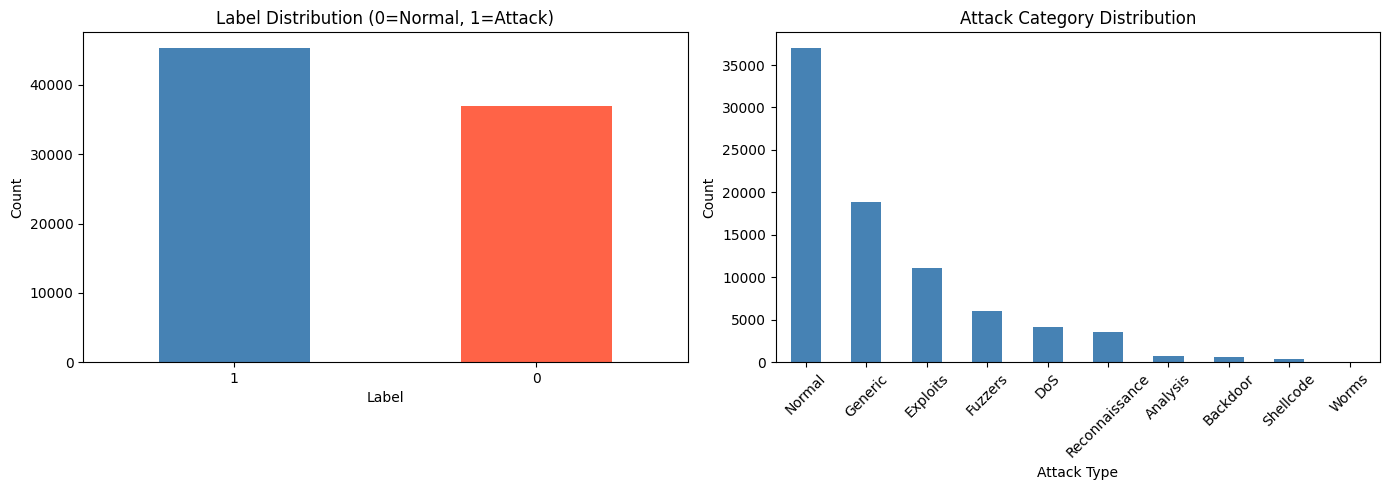

In [6]:
# 레이블 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 레이블 분포
train['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Label Distribution (0=Normal, 1=Attack)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# 공격 유형 분포
train['attack_cat'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Attack Category Distribution')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/eda_distribution.png')
plt.show()

In [7]:
# 피처 타입 확인
print("=== 피처 타입 ===")
print(train.dtypes.value_counts())

print("\n=== 범주형 피처 ===")
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(cat_cols)

print("\n=== 수치형 피처 수 ===")
num_cols = train.select_dtypes(include=np.number).columns.tolist()
print(f"수치형 피처: {len(num_cols)}개")

=== 피처 타입 ===
int64      30
float64    11
object      4
Name: count, dtype: int64

=== 범주형 피처 ===
['proto', 'service', 'state', 'attack_cat']

=== 수치형 피처 수 ===
수치형 피처: 41개
